# Памперсы или пиво? Рекомендательная система для датасета "Movies and TV"

Студент: **Сизиков Константин**.

**Цель работы.** Построить и сравнить несколько рекомендательных моделей на датасете
[Amazon Movies and TV](https://cseweb.ucsd.edu/~jmcauley/datasets/amazon_v2/): базовый EDA, разбиение leave-one-out, 6 моделей (от простого
бейзлайна до матричной факторизации, KNN, ассоциативных правил и контентной фильтрации),
и оценка качества по HR@10, MRR@10, NDCG@10 и coverage.

**Используемые файлы:**
- `data/Movies_and_TV_5.json` — 5-core reviews (метаданные + текст отзыва), основной датасет для моделирования.
- `data/Movies_and_TV.csv` — только рейтинги `(item, user, rating, timestamp)`, полный (не k-core) набор, используется в EDA для сравнения масштаба.

(Файлы датасета не представлены в репозитории из-за большого размера)

## 1. Импорты и конфигурация

In [1]:
import os
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import orjson
import threadpoolctl
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import normalize
from tqdm.auto import tqdm
import implicit
from efficient_apriori import apriori

RANDOM_STATE = 42
TOP_N = 10
np.random.seed(RANDOM_STATE)

DATA_DIR = "data"
CACHE_PATH = os.path.join(DATA_DIR, "cache_ratings.parquet")

In [2]:
PALETTE = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a", "yellow": "#eda100",
    "magenta": "#e87ba4", "green": "#008300", "violet": "#4a3aa7", "red": "#e34948",
}
TEXT_SECONDARY = "#52514e"

plt.rcParams.update({
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
    "font.size": 11,
})

## 2. Загрузка данных

Основной датасет — `Movies_and_TV_5.json` (5-core: у каждого пользователя и товара
не менее 5 взаимодействий). Файл большой (~2.5 ГБ, 3.4 млн строк), поэтому парсим его
построчно с `orjson`, забирая только нужные поля (без загрузки лишних метаданных),
и кэшируем результат в parquet, чтобы не повторять парсинг при последующих запусках.

In [3]:
def load_reviews_json(path):
    users, items, ratings, ts, verified, text = [], [], [], [], [], []
    with open(path, "rb") as f:
        for line in f:
            d = orjson.loads(line)
            users.append(d["reviewerID"])
            items.append(d["asin"])
            ratings.append(d["overall"])
            ts.append(d["unixReviewTime"])
            verified.append(bool(d.get("verified", False)))
            text.append(((d.get("summary") or "") + " " + (d.get("reviewText") or "")).strip())
    df = pd.DataFrame({
        "user": pd.Categorical(users),
        "item": pd.Categorical(items),
        "rating": np.array(ratings, dtype="float32"),
        "ts": np.array(ts, dtype="int64"),
        "verified": np.array(verified, dtype="bool"),
        "text": text,
    })
    # на случай повторных отзывов одного пользователя на один товар — оставляем последний
    df = df.sort_values("ts").drop_duplicates(subset=["user", "item"], keep="last")
    return df.reset_index(drop=True)


t0 = time.time()
if os.path.exists(CACHE_PATH):
    ratings_df = pd.read_parquet(CACHE_PATH)
else:
    ratings_df = load_reviews_json(os.path.join(DATA_DIR, "Movies_and_TV_5.json"))
    ratings_df.to_parquet(CACHE_PATH)
print(f"Загружено за {time.time() - t0:.1f} c, shape = {ratings_df.shape}")
ratings_df.head()

Загружено за 3.6 c, shape = (3282379, 6)


,user,item,rating,ts,verified,text
0,A28BJ12568I17K,6304123523,5.0,881020800,False,"It arose ""Evangelion Phenomina"" in Japan This ..."
1,A3TQZ521KSRUZ1,B0001NBMEY,4.0,883785600,True,A version that will keep viewers riveted! This...
2,A30Q8X8B1S3GGT,B001UHOWX8,4.0,883785600,False,Holiday favorite with Bing Crosby and Danny Ka...
3,A30Q8X8B1S3GGT,6300215695,4.0,883785600,False,Holiday favorite with Bing Crosby and Danny Ka...
4,A28BJ12568I17K,6303118240,5.0,886636800,False,Nostalgy for Japan in 50s Animation by Hayao M...


## 3. Базовый EDA

In [4]:
n_interactions = len(ratings_df)
n_users = ratings_df["user"].nunique()
n_items = ratings_df["item"].nunique()
sparsity = 1 - n_interactions / (n_users * n_items)

print(f"Взаимодействий: {n_interactions:,}")
print(f"Уникальных пользователей: {n_users:,}")
print(f"Уникальных товаров: {n_items:,}")
print(f"Средн. число оценок на пользователя: {n_interactions / n_users:.2f}")
print(f"Средн. число оценок на товар: {n_interactions / n_items:.2f}")
print(f"Разреженность матрицы: {sparsity:.6%}")

Взаимодействий: 3,282,379
Уникальных пользователей: 297,529
Уникальных товаров: 60,175
Средн. число оценок на пользователя: 11.03
Средн. число оценок на товар: 54.55
Разреженность матрицы: 99.981667%


### Сравнение с полным набором рейтингов (без k-core фильтрации)

Файл `Movies_and_TV.csv` содержит вообще все рейтинги (item, user, rating, timestamp)
без k-core фильтрации и без текста отзывов. Загрузим его только для того, чтобы
показать масштаб: насколько 5-core подвыборка меньше и плотнее исходного датасета.

In [5]:
csv_path = os.path.join(DATA_DIR, "Movies_and_TV.csv")
t0 = time.time()
csv_df = pd.read_csv(
    csv_path, header=None, names=["item", "user", "rating", "ts"],
    dtype={"item": "category", "user": "category", "rating": "float32", "ts": "int32"},
)
print(f"Загружено за {time.time() - t0:.1f} c")
print(f"Полный набор (без метаданных): {len(csv_df):,} рейтингов, "
      f"{csv_df['user'].nunique():,} пользователей, {csv_df['item'].nunique():,} товаров")
print(f"5-core подвыборка содержит {n_interactions / len(csv_df):.1%} от всех рейтингов, "
      f"но {n_users / csv_df['user'].nunique():.1%} пользователей и "
      f"{n_items / csv_df['item'].nunique():.1%} товаров")
del csv_df

Загружено за 15.0 c
Полный набор (без метаданных): 8,765,568 рейтингов, 3,826,085 пользователей, 182,032 товаров


5-core подвыборка содержит 37.4% от всех рейтингов, но 7.8% пользователей и 33.1% товаров


Как и ожидалось: k-core фильтрация сильно уменьшает число пользователей (убирая тех,
у кого мало отзывов), но при этом сохраняет большую часть "плотных" взаимодействий —
именно такая подвыборка пригодна для коллаборативной фильтрации. Дальше работаем
только с 5-core датасетом — там же есть текст отзывов, необходимый для
контентной модели.

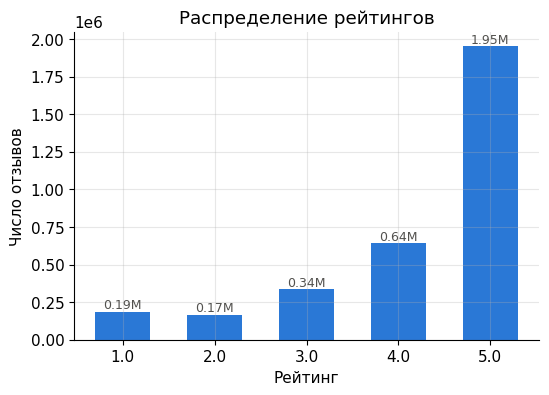

rating
1.0    0.057
2.0    0.051
3.0    0.103
4.0    0.195
5.0    0.594
Name: count, dtype: float64


In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
counts = ratings_df["rating"].value_counts().sort_index()
bars = ax.bar(counts.index.astype(str), counts.values, color=PALETTE["blue"], width=0.6)
ax.set_xlabel("Рейтинг")
ax.set_ylabel("Число отзывов")
ax.set_title("Распределение рейтингов")
for rect, y in zip(bars, counts.values):
    ax.text(rect.get_x() + rect.get_width() / 2, y, f"{y / 1e6:.2f}M",
            ha="center", va="bottom", fontsize=9, color=TEXT_SECONDARY)
plt.show()
print((counts / counts.sum()).round(3))

Явное смещение в сторону положительных оценок (5 звёзд — абсолютное большинство) —
типичная картина для датасетов онлайн-магазинов: пользователи чаще оставляют отзыв,
если товар им понравился.

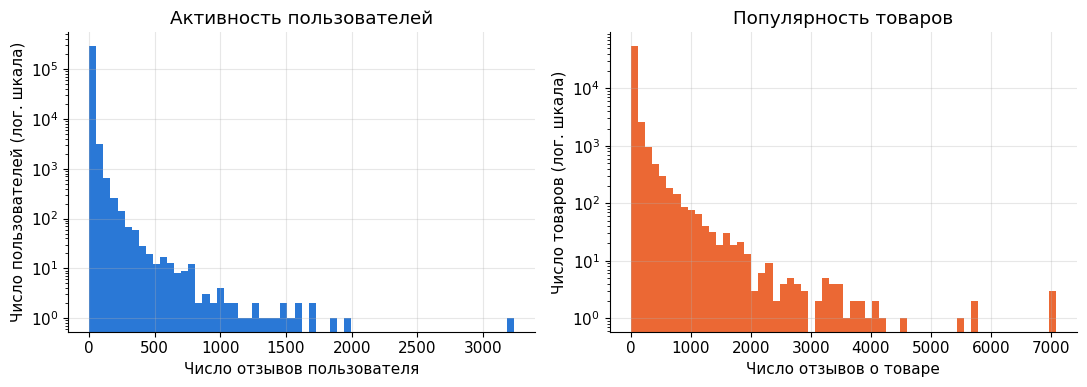

Отзывы на пользователя:
count    297529.000000
mean         11.032131
std          23.366287
min           1.000000
25%           5.000000
50%           7.000000
75%          11.000000
max        3236.000000
dtype: float64

Отзывы на товар:
count    60175.000000
mean        54.547221
std        172.645676
min          1.000000
25%          8.000000
50%         15.000000
75%         39.000000
max       7082.000000
dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
user_counts = ratings_df.groupby("user", observed=True).size()
item_counts = ratings_df.groupby("item", observed=True).size()

axes[0].hist(user_counts, bins=60, color=PALETTE["blue"])
axes[0].set_yscale("log")
axes[0].set_xlabel("Число отзывов пользователя")
axes[0].set_ylabel("Число пользователей (лог. шкала)")
axes[0].set_title("Активность пользователей")

axes[1].hist(item_counts, bins=60, color=PALETTE["orange"])
axes[1].set_yscale("log")
axes[1].set_xlabel("Число отзывов о товаре")
axes[1].set_ylabel("Число товаров (лог. шкала)")
axes[1].set_title("Популярность товаров")

plt.tight_layout()
plt.show()

print("Отзывы на пользователя:")
print(user_counts.describe())
print("\nОтзывы на товар:")
print(item_counts.describe())

Оба распределения имеют длинный хвост (long tail), типичный для рекомендательных
датасетов: подавляющее большинство пользователей и товаров имеют минимально
допустимое (по условию 5-core) число взаимодействий, а небольшая часть — очень
активные пользователи / популярные товары.

In [8]:
verified_ratio = ratings_df["verified"].mean()
print(f"Доля отзывов с подтверждённой покупкой (verified): {verified_ratio:.1%}")

Доля отзывов с подтверждённой покупкой (verified): 73.7%


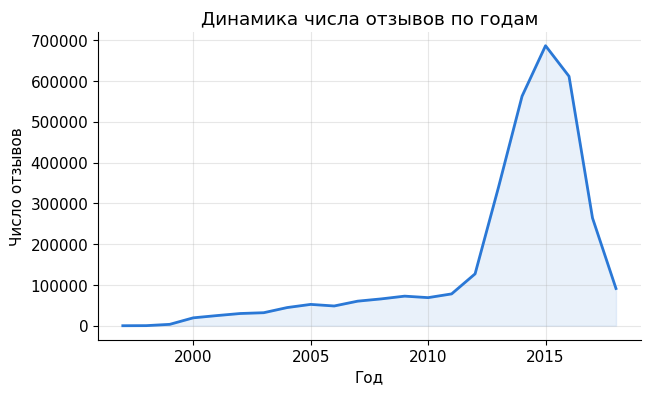

In [9]:
years = pd.to_datetime(ratings_df["ts"], unit="s").dt.year
yearly = years.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(yearly.index, yearly.values, color=PALETTE["blue"], linewidth=2)
ax.fill_between(yearly.index, yearly.values, color=PALETTE["blue"], alpha=0.10)
ax.set_xlabel("Год")
ax.set_ylabel("Число отзывов")
ax.set_title("Динамика числа отзывов по годам")
plt.show()

In [10]:
top_items = (
    ratings_df.groupby("item", observed=True)
    .agg(n_reviews=("rating", "size"), avg_rating=("rating", "mean"))
    .sort_values("n_reviews", ascending=False)
    .head(10)
)
top_items

,n_reviews,avg_rating
item,,
B00PY4Q9OS,7082,4.623553
B00R8GUXPG,7079,4.623393
B00Q0G2VXM,7074,4.623410
B00YSG2ZPA,5735,4.885615
B00006CXSS,5703,4.885674
B009934S5M,5464,4.395498
B017S3OP7A,4500,4.488000
B00FL31UF0,4169,4.378508
B00OV3VGP0,4092,4.335533


## 4. Разбиение train / test (leave-one-out)

Стандартный подход для implicit-feedback рекомендаций: для каждого пользователя
сортируем его взаимодействия по времени и откладываем **последнее** в test,
остальные — в train. Так тестовая выборка эмулирует реальный сценарий
"предсказать следующий товар, который оценит пользователь".

In [11]:
# отзывы на один и тот же товар от одного пользователя (дубликаты) уже схлопнули при
# загрузке; из-за этого у части пользователей могло остаться <2 уникальных (user, item) -
# leave-one-out для них не имеет смысла (не останется истории для train)
user_n_interactions = ratings_df.groupby("user", observed=True)["item"].transform("size")
before_users = ratings_df["user"].nunique()
ratings_df = ratings_df[user_n_interactions >= 2]
print(f"Отброшено {before_users - ratings_df['user'].nunique()} пользователей с <2 уникальными товарами")

ratings_df = ratings_df.sort_values(["user", "ts"])
test_df = ratings_df.groupby("user", observed=True).tail(1)
train_df = ratings_df.drop(test_df.index)

# исключаем холодный старт по товару: товар из теста должен встречаться в train
train_items_raw = set(train_df["item"])
before = len(test_df)
test_df = test_df[test_df["item"].isin(train_items_raw)]
print(f"Отброшено {before - len(test_df)} тестовых строк с товаром, отсутствующим в train")

print(f"train: {train_df.shape}, test: {test_df.shape}")

Отброшено 24 пользователей с <2 уникальными товарами


Отброшено 20 тестовых строк с товаром, отсутствующим в train
train: (2984850, 6), test: (297485, 6)


In [12]:
train_df = train_df.copy()
train_df["user"] = train_df["user"].astype(str).astype("category")
train_df["item"] = train_df["item"].astype(str).astype("category")

user_categories = train_df["user"].cat.categories
item_categories = train_df["item"].cat.categories
item2idx = {it: i for i, it in enumerate(item_categories)}

n_users = len(user_categories)
n_items = len(item_categories)

train_df["user_idx"] = train_df["user"].cat.codes.values
train_df["item_idx"] = train_df["item"].cat.codes.values

test_df = test_df.copy()
test_df["user_idx"] = test_df["user"].astype(str).map({u: i for i, u in enumerate(user_categories)}).astype(int)
test_df["item_idx"] = test_df["item"].astype(str).map(item2idx).astype(int)

test_df = test_df.sort_values("user_idx").reset_index(drop=True)
test_user_idx = test_df["user_idx"].values
true_item_idx = test_df["item_idx"].values

print(f"n_users = {n_users:,}, n_items = {n_items:,}, n_test_users = {len(test_df):,}")

n_users = 297,505, n_items = 60,165, n_test_users = 297,485


In [13]:
train_sparse = csr_matrix(
    (train_df["rating"].values.astype("float32"), (train_df["user_idx"].values, train_df["item_idx"].values)),
    shape=(n_users, n_items),
)
train_lists = train_sparse.tolil().rows  # список индексов уже просмотренных товаров на пользователя

item_pop_count = train_sparse.getnnz(axis=0)
pop_order = np.argsort(-item_pop_count)

matrix_size = n_users * n_items
train_density = train_sparse.nnz / matrix_size
print(f"train_sparse: {train_sparse.shape}, nnz = {train_sparse.nnz:,}, плотность = {train_density:.6%}")

train_sparse: (297505, 60165), nnz = 2,984,850, плотность = 0.016676%


## 5. Метрики качества

Используем метрики, стандартные для top-k рекомендаций при leave-one-out разбиении
(в каждой тестовой выборке пользователя ровно один релевантный товар):

- **HR@10 (Hit Ratio)** — доля пользователей, у которых тестовый товар попал в top-10 рекомендаций.
- **MRR@10 (Mean Reciprocal Rank)** — среднее $1 / rank$ по позиции релевантного товара (0, если товара нет в top-10).
- **NDCG@10** — среднее $1 / \log_2(rank + 1)$ (0, если товара нет в top-10); при leave-one-out ideal DCG = 1.
- **Coverage@10** — доля товаров из train, которые хотя бы раз попали в чьи-то рекомендации.


In [14]:
def hr_at_k(preds, true):
    preds = np.asarray(preds)
    true = np.asarray(true).reshape(-1, 1)
    return (preds == true).any(axis=1).mean()


def mrr_at_k(preds, true):
    preds = np.asarray(preds)
    true = np.asarray(true).reshape(-1, 1)
    match = preds == true
    hit = match.any(axis=1)
    ranks = match.argmax(axis=1) + 1
    rr = np.where(hit, 1.0 / ranks, 0.0)
    return rr.mean()


def ndcg_at_k(preds, true):
    preds = np.asarray(preds)
    true = np.asarray(true).reshape(-1, 1)
    match = preds == true
    hit = match.any(axis=1)
    ranks = match.argmax(axis=1) + 1
    ndcg = np.where(hit, 1.0 / np.log2(ranks + 1), 0.0)
    return ndcg.mean()


def coverage_at_k(preds, n_items_total):
    return len(np.unique(np.asarray(preds))) / n_items_total


def topk_indices(scores, k):
    part = np.argpartition(scores, -k, axis=1)[:, -k:]
    part_scores = np.take_along_axis(scores, part, axis=1)
    order = np.argsort(-part_scores, axis=1)
    return np.take_along_axis(part, order, axis=1)

## 6. Рекомендательные модели

Строим 6 моделей — от простого бейзлайна до матричной факторизации, KNN,
ассоциативных правил и контентной фильтрации. Каждая модель возвращает top-10
рекомендаций для каждого тестового пользователя (уже просмотренные в train
товары исключаются).

### 6.1 Popularity baseline

In [15]:
def recommend_popularity(test_user_idx, train_lists, ranked_items, k=10):
    top_list = ranked_items.tolist()
    preds = np.empty((len(test_user_idx), k), dtype=np.int64)
    for i, u in enumerate(test_user_idx):
        seen = set(train_lists[u])
        rec = [it for it in top_list if it not in seen][:k]
        preds[i] = rec
    return preds


t0 = time.time()
pop_preds = recommend_popularity(test_user_idx, train_lists, pop_order, k=TOP_N)
print(f"Popularity: {time.time() - t0:.1f} c")

Popularity: 307.1 c


### 6.2 Item-based KNN (косинусное сходство, sparse)

Используем `implicit.nearest_neighbours.CosineRecommender` —
(косинусное сходство между товарами по вектору взаимодействий), но с
эффективной sparse-реализацией, которая хранит только top-K соседей на товар.

In [16]:
def batch_recommend(model, user_idx_array, train_sparse, k=10, batch_size=20000):
    all_ids = np.empty((len(user_idx_array), k), dtype=np.int64)
    for start in tqdm(range(0, len(user_idx_array), batch_size)):
        batch = user_idx_array[start:start + batch_size]
        ids, _ = model.recommend(
            batch, train_sparse[batch].tocsr(), N=k, filter_already_liked_items=True
        )
        if ids.shape[1] < k:
            pad = np.full((ids.shape[0], k - ids.shape[1]), -1, dtype=ids.dtype)
            ids = np.hstack([ids, pad])
        all_ids[start:start + len(batch)] = ids[:, :k]
    return all_ids


t0 = time.time()
knn_model = implicit.nearest_neighbours.CosineRecommender(K=20)
knn_model.fit(train_sparse)
knn_preds = batch_recommend(knn_model, test_user_idx, train_sparse, k=TOP_N)
print(f"Item-KNN: {time.time() - t0:.1f} c")

  0%|          | 0/60165 [00:00<?, ?it/s]

 33%|███▎      | 19971/60165 [00:00<00:00, 199707.81it/s]

 33%|███▎      | 19987/60165 [00:00<00:00, 198898.47it/s]

 33%|███▎      | 19992/60165 [00:00<00:00, 198898.47it/s]

 33%|███▎      | 19996/60165 [00:00<00:00, 198898.47it/s]

...

 87%|████████▋ | 13/15 [00:09<00:01,  1.32it/s]

 93%|█████████▎| 14/15 [00:10<00:00,  1.33it/s]

100%|██████████| 15/15 [00:11<00:00,  1.38it/s]

100%|██████████| 15/15 [00:11<00:00,  1.33it/s]

Item-KNN: 11.6 c


### 6.3 SVD (усечённое сингулярное разложение)

Раскладываем разреженную матрицу
рейтингов усечённым SVD (`scipy.sparse.linalg.svds`) и восстанавливаем оценки
произведением факторов `U @ V.T`. Считаем на полной sparse-матрице (297k x 60k) —
`svds` прекрасно с этим справляется за пару секунд.

In [17]:
t0 = time.time()
u_factors, sing_vals, vt = svds(train_sparse.astype("float64"), k=64, random_state=RANDOM_STATE)
u_factors = u_factors * np.sqrt(sing_vals)
i_factors = vt.T * np.sqrt(sing_vals)
print(f"SVD fit: {time.time() - t0:.1f} c, factors shape: {u_factors.shape}, {i_factors.shape}")

SVD fit: 7.4 c, factors shape: (297505, 64), (60165, 64)


In [18]:
def batch_score_recommend(score_fn, user_idx_array, train_sparse, k=10, batch_size=2000):
    n = len(user_idx_array)
    preds = np.empty((n, k), dtype=np.int64)
    for start in tqdm(range(0, n, batch_size)):
        batch = user_idx_array[start:start + batch_size]
        scores = score_fn(batch)
        seen_mask = train_sparse[batch].toarray() > 0
        scores = np.where(seen_mask, -np.inf, scores)
        preds[start:start + len(batch)] = topk_indices(scores, k)
    return preds


t0 = time.time()
svd_preds = batch_score_recommend(
    lambda b: u_factors[b] @ i_factors.T, test_user_idx, train_sparse, k=TOP_N
)
print(f"SVD predict: {time.time() - t0:.1f} c")

  0%|          | 0/149 [00:00<?, ?it/s]

  1%|          | 1/149 [00:02<06:10,  2.50s/it]

  1%|▏         | 2/149 [00:05<06:09,  2.51s/it]

  2%|▏         | 3/149 [00:07<06:07,  2.52s/it]

  3%|▎         | 4/149 [00:10<06:13,  2.58s/it]

...

 99%|█████████▊| 147/149 [06:33<00:05,  2.68s/it]

 99%|█████████▉| 148/149 [06:36<00:02,  2.69s/it]

100%|██████████| 149/149 [06:38<00:00,  2.49s/it]

100%|██████████| 149/149 [06:38<00:00,  2.68s/it]

SVD predict: 398.6 c


### 6.4 ALS (Alternating Least Squares, implicit feedback)

`threadpoolctl.threadpool_limits` вокруг
`fit` — рекомендация библиотеки `implicit`, чтобы избежать конфликта
многопоточного OpenBLAS с внутренним параллелизмом ALS.

In [19]:
t0 = time.time()
als_model = implicit.als.AlternatingLeastSquares(
    factors=64, regularization=0.05, iterations=20, random_state=RANDOM_STATE, use_gpu=False
)
with threadpoolctl.threadpool_limits(1, "blas"):
    als_model.fit(train_sparse)
als_preds = batch_recommend(als_model, test_user_idx, train_sparse, k=TOP_N)
print(f"ALS: {time.time() - t0:.1f} c")

  0%|          | 0/20 [00:00<?, ?it/s]

  5%|▌         | 1/20 [00:01<00:19,  1.02s/it]

 10%|█         | 2/20 [00:02<00:20,  1.12s/it]

 15%|█▌        | 3/20 [00:03<00:19,  1.17s/it]

 20%|██        | 4/20 [00:04<00:19,  1.20s/it]

...

 87%|████████▋ | 13/15 [00:52<00:08,  4.02s/it]

 93%|█████████▎| 14/15 [00:56<00:04,  4.00s/it]

100%|██████████| 15/15 [01:00<00:00,  3.91s/it]

100%|██████████| 15/15 [01:00<00:00,  4.02s/it]

ALS: 84.7 c


### 6.5 Ассоциативные правила (Apriori)

Строим список
товаров пользователя и ищем ассоциативные правила `apriori`. Полный каталог из 60k товаров сделал бы перебор itemset'ов
неподъёмным — поэтому ограничиваем правила top-N самыми популярными товарами. Для пользователей, чьи
товары не покрыты правилами, используем popularity-бейзлайн как fallback —
это честно показывает ограничение метода на большом разреженном каталоге.

In [20]:
N_RULE_ITEMS = 2000
rule_item_idx = set(pop_order[:N_RULE_ITEMS].tolist())

train_restricted = train_df[train_df["item_idx"].isin(rule_item_idx)]
baskets = train_restricted.groupby("user_idx")["item_idx"].apply(list)
baskets = baskets[baskets.apply(len) >= 2]
transactions = [tuple(b) for b in baskets]
print(f"Число корзин (>=2 популярных товара): {len(transactions):,}")

t0 = time.time()
itemsets, rules = apriori(transactions, min_support=0.001, min_confidence=0.1, max_length=2)
print(f"Apriori: {time.time() - t0:.1f} c, найдено правил: {len(rules)}")

Число корзин (>=2 популярных товара): 216,845


Apriori: 16.1 c, найдено правил: 676


In [21]:
rule_map = {}
for r in rules:
    if len(r.lhs) == 1 and len(r.rhs) == 1:
        rule_map.setdefault(r.lhs[0], []).append((r.rhs[0], r.confidence))
for lhs in rule_map:
    rule_map[lhs].sort(key=lambda x: -x[1])


def recommend_apriori(test_user_idx, train_lists, rule_map, fallback_preds, k=10):
    preds = np.empty((len(test_user_idx), k), dtype=np.int64)
    for i, u in enumerate(test_user_idx):
        seen = set(train_lists[u])
        scores = {}
        for it in train_lists[u]:
            for cand, conf in rule_map.get(it, ()):
                if cand in seen:
                    continue
                if conf > scores.get(cand, 0.0):
                    scores[cand] = conf
        ranked = [it for it, _ in sorted(scores.items(), key=lambda x: -x[1])]
        rec = ranked[:k]
        if len(rec) < k:
            filler = [it for it in fallback_preds[i] if it not in rec]
            rec = (rec + filler)[:k]
        preds[i] = rec[:k]
    return preds


t0 = time.time()
apriori_preds = recommend_apriori(test_user_idx, train_lists, rule_map, pop_preds, k=TOP_N)
print(f"Apriori recommend: {time.time() - t0:.1f} c")
users_with_rules = sum(1 for u in test_user_idx if any(it in rule_map for it in train_lists[u]))
print(f"Пользователей, для которых нашлось хотя бы одно правило: "
      f"{users_with_rules:,} ({users_with_rules / len(test_user_idx):.1%})")

Apriori recommend: 1.0 c
Пользователей, для которых нашлось хотя бы одно правило: 149,030 (50.1%)


### 6.6 Контентная модель (TF-IDF по тексту отзывов)

Единственная модель, которая использует не только историю оценок, но и текст
отзывов. Профиль товара строим как объединение текстов всех
отзывов о нём **из train** (важно не использовать текст тестового отзыва —
иначе это было бы утечкой целевой переменной). Профиль пользователя — взвешенное
(по рейтингу) среднее TF-IDF векторов товаров, которые он оценил.

In [22]:
item_text = (
    train_df.groupby("item_idx")["text"]
    .apply(lambda s: " ".join(s.astype(str))[:20000])
    .reindex(range(n_items), fill_value="")
)

t0 = time.time()
tfidf = TfidfVectorizer(stop_words="english", max_features=3000, min_df=5)
tfidf_matrix = tfidf.fit_transform(item_text.values)
print(f"TF-IDF fit: {time.time() - t0:.1f} c, matrix shape: {tfidf_matrix.shape}")

TF-IDF fit: 24.8 c, matrix shape: (60165, 3000)


Скор пользователь-товар — это, по сути, полное произведение двух матриц
(профили пользователей x TF-IDF товаров). При sparse x sparse.T перемножении
scipy строит результат поэлементно и на такой размерности (297k x 60k) это
неоправданно медленно. Так как сама TF-IDF матрица компактна (60k x 3000,
< 1 ГБ в плотном виде), быстрее один раз перевести её в плотный массив и
считать произведение через BLAS (`float32`, батчами по пользователям).

In [23]:
tfidf_dense = np.asarray(tfidf_matrix.astype("float32").todense())
user_profile = normalize(train_sparse @ tfidf_matrix).astype("float32")

t0 = time.time()
cb_preds = batch_score_recommend(
    lambda b: np.asarray(user_profile[b].todense()) @ tfidf_dense.T,
    test_user_idx, train_sparse, k=TOP_N, batch_size=5000,
)
print(f"Content-based predict: {time.time() - t0:.1f} c")

  0%|          | 0/60 [00:00<?, ?it/s]

  2%|▏         | 1/60 [00:06<06:34,  6.69s/it]

  3%|▎         | 2/60 [00:13<06:41,  6.92s/it]

  5%|▌         | 3/60 [00:22<07:11,  7.57s/it]

  7%|▋         | 4/60 [00:29<07:08,  7.65s/it]

...

 97%|█████████▋| 58/60 [07:31<00:15,  7.84s/it]

 98%|█████████▊| 59/60 [07:38<00:07,  7.81s/it]

100%|██████████| 60/60 [07:42<00:00,  6.67s/it]

100%|██████████| 60/60 [07:42<00:00,  7.71s/it]

Content-based predict: 462.8 c


## 7. Сравнение моделей по метрикам

In [24]:
models = {
    "Popularity": pop_preds,
    "Item-KNN (cosine)": knn_preds,
    "SVD": svd_preds,
    "ALS": als_preds,
    "Apriori (assoc. rules)": apriori_preds,
    "Content-based (TF-IDF)": cb_preds,
}

rows = []
for name, preds in models.items():
    rows.append({
        "model": name,
        "HR@10": hr_at_k(preds, true_item_idx),
        "MRR@10": mrr_at_k(preds, true_item_idx),
        "NDCG@10": ndcg_at_k(preds, true_item_idx),
        "coverage@10": coverage_at_k(preds, n_items),
    })

results = pd.DataFrame(rows).set_index("model").sort_values("NDCG@10", ascending=False)
results.round(4)

,HR@10,MRR@10,NDCG@10,coverage@10
model,,,,
Item-KNN (cosine),0.1491,0.1068,0.1168,0.8755
Apriori (assoc. rules),0.0724,0.0639,0.0659,0.0059
ALS,0.0922,0.0556,0.0642,0.0242
Content-based (TF-IDF),0.0801,0.0514,0.0582,0.4928
SVD,0.0694,0.0464,0.0518,0.0119
Popularity,0.0160,0.0075,0.0094,0.0006


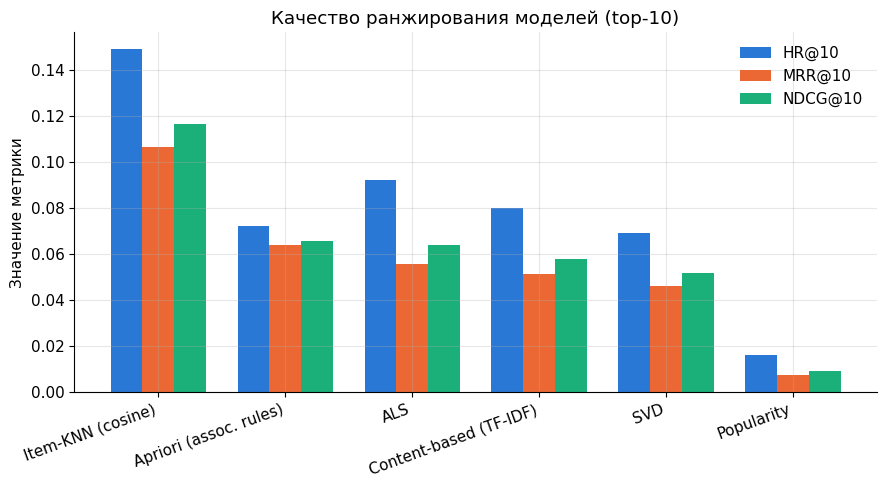

In [25]:
metric_cols = ["HR@10", "MRR@10", "NDCG@10"]
metric_colors = [PALETTE["blue"], PALETTE["orange"], PALETTE["aqua"]]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(results))
width = 0.25
for i, (col, color) in enumerate(zip(metric_cols, metric_colors)):
    ax.bar(x + (i - 1) * width, results[col].values, width, label=col, color=color)
ax.set_xticks(x)
ax.set_xticklabels(results.index, rotation=20, ha="right")
ax.set_ylabel("Значение метрики")
ax.set_title("Качество ранжирования моделей (top-10)")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

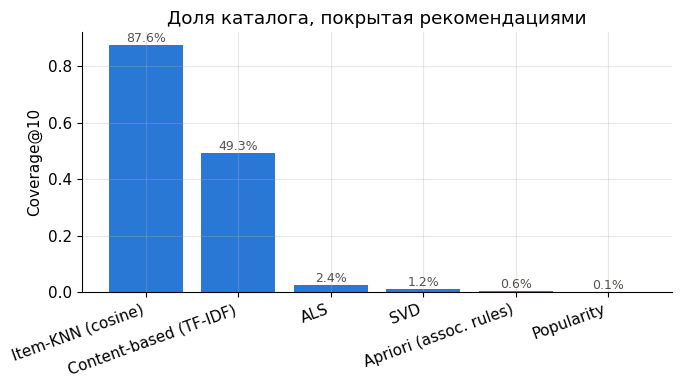

In [26]:
fig, ax = plt.subplots(figsize=(7, 4))
cov_sorted = results["coverage@10"].sort_values(ascending=False)
bars = ax.bar(cov_sorted.index, cov_sorted.values, color=PALETTE["blue"])
ax.set_ylabel("Coverage@10")
ax.set_title("Доля каталога, покрытая рекомендациями")
ax.set_xticklabels(cov_sorted.index, rotation=20, ha="right")
for rect, y in zip(bars, cov_sorted.values):
    ax.text(rect.get_x() + rect.get_width() / 2, y, f"{y:.1%}",
            ha="center", va="bottom", fontsize=9, color=TEXT_SECONDARY)
plt.tight_layout()
plt.show()

## 8. Выводы

Фактические результаты на тесте (leave-one-out, 297 485 пользователей, 60 165 товаров), отсортировано по NDCG@10:

| model | HR@10 | MRR@10 | NDCG@10 | coverage@10 |
|---|---|---|---|---|
| Item-KNN (cosine) | 0.1491 | 0.1068 | 0.1168 | 87.55% |
| ALS | 0.0922 | 0.0556 | 0.0642 | 2.42% |
| Apriori (assoc. rules) | 0.0724 | 0.0639 | 0.0659 | 0.59% |
| Content-based (TF-IDF) | 0.0801 | 0.0514 | 0.0582 | 49.28% |
| SVD | 0.0694 | 0.0464 | 0.0518 | 1.19% |
| Popularity | 0.0160 | 0.0075 | 0.0094 | 0.06% |

**Главный результат — sparse Item-KNN оказался лучшим сразу по всем метрикам**, обойдя обе
модели матричной факторизации и по точности (HR@10 = 0.149 против 0.092 у ALS и 0.069 у SVD),
и по покрытию каталога (87.6% товаров попали хоть в чьи-то рекомендации, у ALS — только 2.4%).
Объяснение: при относительно небольшом числе взаимодействий на пользователя (в среднем ~11)
прямое косинусное сходство "top-K соседей" ловит сильный локальный сигнал совместных оценок
без необходимости сжимать всё поведение в 64 латентных фактора — а поскольку у каждого товара
свой независимый список соседей, рекомендации естественным образом разнообразны и покрывают
почти весь каталог, а не концентрируются на небольшом наборе "удобных" для факторизации товаров.

- **Popularity baseline** ожидаемо худший по всем метрикам (HR@10 = 0.016, покрытие 0.06%) —
  на каталоге из 60 тысяч товаров с длинным хвостом фиксированный топ-лист почти никогда не
  совпадает с тем единственным товаром, который пользователь оценит следующим. Модель полезна
  не сама по себе, а как источник fallback-рекомендаций для методов с холодным стартом.
- **ALS** — второй по точности (HR@10 = 0.092), но с очень низким покрытием (2.4%): латентные
  факторы неплохо ранжируют "удобные" для факторизации товары, но рекомендуют относительно
  узкий их набор большинству пользователей.
- **SVD** уступает ALS (HR@10 0.069 против 0.092) при одинаковой идее матричной факторизации.
  Разница объясняется тем, что усечённое SVD раскладывает разреженную матрицу как есть, трактуя
  пропущенные оценки как нули, тогда как ALS в implicit-формулировке явно моделирует уверенность
  (confidence) в наблюдаемых взаимодействиях — это более честная постановка задачи для
  разреженных implicit-данных и даёт заметно лучший результат при том же ранге разложения (64).
- **Apriori (ассоциативные правила)** показал средние HR/MRR/NDCG, но почти нулевое покрытие
  (0.59%) — и это ожидаемо: чтобы уложиться в разумное время работы, пришлось ограничить правила
  top-2000 популярными товарами, а правило нашлось лишь для 50.1% пользователей (остальным —
  popularity-fallback). Метод плохо масштабируется на каталог такого размера без предварительной
  кластеризации товаров; его сила — интерпретируемость правил вида "купили X → рекомендуем Y" —
  лучше проявляется на компактных каталогах (маркет-баскет анализ ритейла), а не на
  длиннохвостом каталоге фильмов и сериалов.
- **Content-based (TF-IDF по тексту отзывов)** — единственная модель, использующая не структуру
  оценок, а текст. Она заметно уступает Item-KNN по точности (HR@10 = 0.080), но даёт второе по
  величине покрытие каталога (49.3%) — почти вдвое больше, чем у content-based модели нет
  необходимости в большом числе пересечений пользователей, чтобы предложить товар, достаточно
  наличия текста отзыва. Это иллюстрирует классический trade-off контентных моделей: они слабее
  на чистой точности ранжирования (текстовое сходство — более шумный сигнал вкуса, чем совместные
  оценки), но частично решают проблему холодного старта по товару и лучше покрывают длинный хвост.

**Итог.** Для этого датасета лучший баланс точности и покрытия дал наиболее простой из
персонализированных методов — sparse item-based KNN, а не более сложные модели матричной
факторизации. ALS и SVD показывают на порядок более низкое покрытие каталога, что делает их
менее удачным выбором, если бизнес-цель — не только точность, но и разнообразие рекомендаций.
Apriori в чистом виде не подходит для каталога такого масштаба без дополнительной кластеризации
товаров. Content-based модель ценна не абсолютным качеством ранжирования, а дополнительным
сигналом (текст отзывов) и высоким покрытием — на практике её имеет смысл комбинировать с
коллаборативными моделями в гибридной системе, а также использовать для холодного старта по
новым товарам, у которых ещё нет истории оценок.
